# Generate Conditional Random Field (CRF) 
The CRF field contains:
1. prior information using SLE inversion (done first)
2. Apply geostatistic to analysis the statistics paramters
3. Conditional point and value sampling  

In [2]:
import os
import numpy as np
import pandas as pd
import gstools as gs
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from sklearn.metrics import r2_score
import plotly.graph_objects as go
from gstools.random import MasterRNG
from plotly.subplots import make_subplots
from utilies import *

plt.rcParams["font.family"] = "Times New Roman"

### functions (later put on utilies.py)

In [ ]:
def plot_3d_isosurfaces(df_cor, col_name, iso_num, iso_range, title):
    """
    Parameters:
    -----------
    df_cor : pandas.DataFrame
        A DataFrame containing the 3D coordinates and the corresponding scalar values for plotting.
        Expected columns: ['x', 'y', 'z', col_name]

    col_name : str
        The name of the column in `df_cor` to be used for isosurface plotting.

    iso_num : int
        The number of isosurfaces to be plotted.

    iso_range : list or tuple of float
        The value range for the isosurfaces. Should be specified as [min_value, max_value].

    title : str
        The title of the figure to be displayed.
    """

    value = df_cor[col_name].values
    iso_min, iso_max = iso_range

    fig = go.Figure()

    fig.add_trace(go.Isosurface(
        x=df_cor['x'].values,
        y=df_cor['y'].values,
        z=df_cor['z'].values,
        value=value,
        isomin=iso_min,
        isomax=iso_max,
        surface_count=iso_num,
        colorscale='RdYlBu',   # 注意大小寫，建議用官方名稱
        showscale=True,
        opacity=0.4,
        caps=dict(x_show=False, y_show=False, z_show=False),

        colorbar=dict(
            title=dict(
                text=title,
                font=dict(size=18, family='Times New Roman', color='black')
            ),
            thickness=30,
            x=0.9,
            len=1.0,
            tickfont=dict(size=16)
        ),
    ))

    fig.update_layout(
        title=dict(
            text=title,
            x=0.5,
            y=0.95,
            xanchor='center',
            font=dict(size=36, family='Times New Roman')
        ),
        autosize=True,
        width=750,
        height=600,
        margin=dict(l=10, r=10, t=50, b=10),

        scene=dict(
            camera=dict(
                eye=dict(x=1, y=2, z=1),
            ),
            xaxis=dict(
                gridcolor='lightgray',
                showbackground=True,
                showline=True,
                linecolor='black',
                linewidth=2,
                showticklabels=False,
            ),
            yaxis=dict(
                gridcolor='lightgray',
                showbackground=True,
                showline=True,
                linecolor='black',
                linewidth=2,
                showticklabels=False,
            ),
            zaxis=dict(
                gridcolor='lightgray',
                showbackground=True,
                showline=True,
                linecolor='black',
                linewidth=2,
                showticklabels=False,
            ),
            aspectmode='data'
        ),
        font=dict(family="Times New Roman", size=20),
    )

    return fig

In [ ]:
def plot_all_contours(df, col_name, value_range, contour_num, figsize):
    """
    df: 包含 x, y, z 與目標欄位的 DataFrame
    col_name: 要畫 contour 的欄位名稱
    value_range: (zmin, zmax)
    contour_num: contour 數量
    figsize: (width, height)
    """

    # -------- 基本檢查 --------
    required_cols = {'x', 'y', 'z', col_name}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"df 缺少必要欄位: {missing}")

    all_z = sorted(df['z'].unique())
    z_values = [z for i, z in enumerate(all_z) if i % 2 == 0]   # 每隔一層取一層
    # z_values = all_z  # 如果要全部層都畫，改成這行

    z_min, z_max = value_range

    # 深度標題
    check_depth = ['126', '108', '90', '72', '54', '36']
    if len(check_depth) >= len(z_values):
        subplot_titles = [f"Depth = {d} cm" for d in check_depth[:len(z_values)]]
    else:
        subplot_titles = [f"z = {z}" for z in z_values]

    # -------- 建立井位資料 --------
    well_data = [
        ("Pie_1", 188.5, 71),
        ("Pie_2", 88.5, 131),
        ("Pie_3", 88.5, 251),
        ("Pie_4", 188.5, 311),
        ("Pie_5", 388.5, 311),
        ("Pie_6", 488.5, 251),
        ("Pie_7", 488.5, 131),
        ("Pie_8", 388.5, 71),

        ("Inj_1", 288.5, 71),
        ("Inj_2", 88.5, 71),
        ("Inj_3", 88.5, 191),
        ("Inj_4", 88.5, 311),
        ("Inj_5", 288.5, 311),
        ("Inj_6", 488.5, 311),
        ("Inj_7", 488.5, 191),
        ("Inj_8", 488.5, 71),
    ]
    well_df = pd.DataFrame(well_data, columns=["name", "x", "y"])

    # 如果 contour 圖的座標是公尺，而井位目前是 cm，請轉成 m
    # well_df["x"] = well_df["x"] / 10
    # well_df["y"] = well_df["y"] / 10

    # 分類不同井位
    pie_df = well_df[well_df["name"].str.startswith("Pie")]
    inj_df = well_df[well_df["name"].str.startswith("Inj")]

    # -------- 建立子圖 --------
    fig = make_subplots(
        rows=len(z_values),
        cols=1,
        subplot_titles=subplot_titles,
        vertical_spacing=0.02,
        shared_xaxes=True
    )

    # -------- 逐層畫 contour --------
    for i, z in enumerate(z_values):
        df_slice = df[df["z"] == z].copy()

        if df_slice.empty:
            print(f"Warning: z={z} 沒有資料，跳過")
            continue

        pivot_df = df_slice.pivot_table(index="y", columns="x", values=col_name)

        xi = pivot_df.columns.values
        yi = pivot_df.index.values
        zi = pivot_df.values

        # contour
        fig.add_trace(
            go.Contour(
                x=xi,
                y=yi,
                z=zi,
                zmin=z_min,
                zmax=z_max,
                colorscale='RdYlBu_r',
                opacity=0.8,
                ncontours=contour_num,
                line=dict(width=0.25, color='#333333'),
                coloraxis="coloraxis",
                showscale=False
            ),
            row=i+1, col=1
        )

        # Pie 井位
        fig.add_trace(
            go.Scatter(
                x=pie_df["x"],
                y=pie_df["y"],
                mode='markers+text',
                text=pie_df["name"],
                textposition='top right',
                textfont=dict(family="Times New Roman", size=11, color="blue"),
                marker=dict(size=7, color='blue', symbol='circle'),
                name='Pie well',
                showlegend=(i == 0)   # 只在第一張子圖顯示 legend
            ),
            row=i+1, col=1
        )

        # Inj 井位
        fig.add_trace(
            go.Scatter(
                x=inj_df["x"],
                y=inj_df["y"],
                mode='markers+text',
                text=inj_df["name"],
                textposition='top right',
                textfont=dict(family="Times New Roman", size=11, color="red"),
                marker=dict(size=7, color='red', symbol='square'),
                name='Injection well',
                showlegend=(i == 0)
            ),
            row=i+1, col=1
        )

    # -------- 調整 subplot 標題位置 --------
    for i in range(len(fig.layout.annotations)):
        y_ref_str = 'y domain' if i == 0 else f'y{i+1} domain'
        fig.layout.annotations[i].update(
            x=0.9,
            yref=y_ref_str,
            y=0.03,
            xanchor='right',
            yanchor='bottom',
            font=dict(size=14, family="Times New Roman", color="black"),
            bgcolor="rgba(255,255,255,0.7)"
        )

    # -------- 全域 layout --------
    fig.update_layout(
        height=figsize[1],
        width=figsize[0],
        template="plotly_white",
        font=dict(family="Times New Roman"),
        margin=dict(l=20, r=20, t=20, b=60),

        coloraxis=dict(
            colorscale='RdYlBu',
            cmin=z_min,
            cmax=z_max,
            colorbar=dict(
                title=dict(
                    text='lnK',
                    side='top'
                ),
                orientation='h',
                thickness=18,
                len=0.7,
                x=0.5,
                xanchor='center',
                y=-0.06,
                yanchor='top',
                outlinewidth=0,
                tickfont=dict(family="Times New Roman", size=12)
            )
        ),

        legend=dict(
            orientation="h",
            x=0.5,
            xanchor="center",
            y=1.02,
            yanchor="bottom"
        )
    )

    # -------- 統一座標軸字體 --------
    fig.update_xaxes(
        tickfont=dict(family="Times New Roman", size=12),
        title_font=dict(family="Times New Roman", size=16)
    )
    fig.update_yaxes(
        tickfont=dict(family="Times New Roman", size=12),
        title_font=dict(family="Times New Roman", size=16)
    )

    # 中間那張圖加 Y 軸標題
    middle_row = (len(z_values) // 2) + 1
    fig.update_yaxes(
        title_text="Y (m)",
        row=middle_row, col=1
    )

    # 清空所有 X 軸標題
    for r in range(1, len(z_values)+1):
        fig.update_xaxes(title_text="", row=r, col=1)

    # 最後一張圖加 X 軸標題
    fig.update_xaxes(
        title_text="X (m)",
        row=len(z_values), col=1
    )

    fig.show()
    return fig

### Import prior K

In [ ]:
# Prior K value using 16-th iteration from SLE inversion
iter = 16
file_name = "inverse/O-kestimate_prior.dat"
df_mean, df_var = parse_estimation(file_name, dim =3)

df_prior = df_mean[['x', 'y', 'z', f'iter_{iter}']].copy()
df_prior['lnK_Var'] = df_var[f'iter_{iter}'].values
df_prior['K'] = df_prior[f'iter_{iter}'].values
df_prior['log_K'] = np.log(df_prior[f'iter_{iter}'].values)

df_prior_core = df_prior[
    (df_prior['x'] >= 132) & (df_prior['x'] <= 445) &
    (df_prior['y'] >= 96) & (df_prior['y'] <= 286) &
    (df_prior['z'] >= 95) & (df_prior['z'] <= 195)
]

### Histogram plot

In [ ]:
col_all = df_prior[f'iter_{iter}'].dropna()
col_core = df_prior_core[f'iter_{iter}'].dropna()

log_all = np.log(col_all[col_all > 0])
log_core = np.log(col_core[col_core > 0])

fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=300)

# --- 1. prior 全域 ---
axes[0, 0].hist(col_all, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
axes[0, 0].set_title("Prior field (all)", fontsize=16)
axes[0, 0].set_xlabel("Value", fontsize=13)
axes[0, 0].set_ylabel("Frequency", fontsize=13)
axes[0, 0].grid(alpha=0.3)

# --- 2. prior core ---
axes[0, 1].hist(col_core, bins=50, color='darkorange', edgecolor='black', alpha=0.8)
axes[0, 1].set_title("Prior field (core)", fontsize=16)
axes[0, 1].set_xlabel("Value", fontsize=13)
axes[0, 1].set_ylabel("Frequency", fontsize=13)
axes[0, 1].grid(alpha=0.3)

# --- 3. log(prior 全域) ---
axes[1, 0].hist(log_all, bins=50, color='seagreen', edgecolor='black', alpha=0.8)
axes[1, 0].set_title("log(Prior field, all)", fontsize=16)
axes[1, 0].set_xlabel("log(Value)", fontsize=13)
axes[1, 0].set_ylabel("Frequency", fontsize=13)
axes[1, 0].grid(alpha=0.3)

# --- 4. log(prior core) ---
axes[1, 1].hist(log_core, bins=50, color='firebrick', edgecolor='black', alpha=0.8)
axes[1, 1].set_title("log(Prior field, core)", fontsize=16)
axes[1, 1].set_xlabel("log(Value)", fontsize=13)
axes[1, 1].set_ylabel("Frequency", fontsize=13)
axes[1, 1].grid(alpha=0.3)

for ax in axes.ravel():
    ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()
# plt.savefig("")
plt.show()

### 3D plot for priro information

In [ ]:
plot_3d_isosurfaces(df_prior, f'iter_{iter}', 8, [1, 2], 'K')
# plot_3d_isosurfaces(df_prior_core, 'log_K', 8, [-1, 1], 'lnK')

### 2D slice contour plot prior information

In [ ]:
# fig = plot_all_contours(df_prior_core, f'iter_{iter}', [1, 2], 15, (600, 3600))
fig = plot_all_contours(df_prior, 'log_K', [-1, 1], 15, (600, 4800))

## Geostatistics analysis

### Data interpolation

In [5]:
xg, yg, zg, inter_inK = interpolate_3d(df_prior_core, value_col=f'iter_{iter}', grid_size=[120, 60, 80], method="linear")

### Variogram estimation

In [ ]:
df_geo = pd.DataFrame({'x': xg.flatten(),
                       'y': yg.flatten(),
                       'z': zg.flatten(),
                       'mean': inter_inK.flatten()})
# plot_3d_isosurfaces(df_geo, 'ln_mean', 5, [-10, -7], 'SLE lnK interpolation')

bins_x = np.arange(0,  200 ,  10)
bins_y = np.arange(0,  150,   10)
bins_z = np.arange(0,  120,   10)

plt.figure(figsize = (10, 6))
variogram_test(coordinate = (xg,yg,zg), value=df_geo['mean'], bins= bins_x, direction='X', max_dis = 200)
plt.show()
variogram_test(coordinate = (xg,yg,zg), value=df_geo['mean'], bins= bins_y, direction='Y', max_dis = 150)
plt.show()
variogram_test(coordinate = (xg,yg,zg), value=df_geo['mean'], bins= bins_z, direction='Z', max_dis = 110)
plt.show()

## CRF generation

### Process
1. Injection well appointment
1. Conditional data sampling
2. Conditional value sampling
3. Conditional random field generate

### CRF parameters

In [8]:
#-- reagent injection well info 
df_prior.head()

injA_data  = [
        ("injA_1",  288.5,  101, 150),
        ("injA_2",  288.5,  146, 150),
        ("injA_3",  143.5,  191, 150),
        ("injA_4",  196,	191, 150),
        ("injA_5",  241,	191, 150),
        ("injA_6",  336,	191, 150),
        ("injA_7",  381,	191, 150),
        ("injA_8",  433.5,  191, 150),
        ("injA_9",  288.5,  236, 150),
        ("injA_10", 288.5,  281, 150),
        # ("Middle", 288.5,  191, 150,)
    ]

injA_df = pd.DataFrame(injA_data, columns=["name", "x", "y", "z"])
# plt.scatter(injA_df['x'], injA_df['y'])

#-- Setting dataframe for conditional random field
df_est = pd.DataFrame({'x': df_prior['x'],
                       'y': df_prior['y'],
                       'z': df_prior['z'],
                       'K': df_prior['K'],
                       'ln_var': df_prior['lnK_Var']})

coordinate = df_est[['x', 'y', 'z']]

#-- prior geostatistics and crf condition info
crf_params = {
    "ens_num":4,
    "seed": 20260629,
    "model": "Gaussian",
    "variance": 0.09,
    "correlation_scale": {"x": 50, "y": 60, "z": 47},
    "c_scale_mul": 1.5,
    "inj_A_num": len(injA_df),
    "section_sample_num": 1,
    "fraction_rate": 0.25,
    "resample_time": 2,
    "contain_rate": 0.5
    }

for key, para in crf_params.items():
    print(f'{key}: {para}')

ens_num: 4
seed: 20260629
model: Gaussian
variance: 0.09
correlation_scale: {'x': 50, 'y': 60, 'z': 47}
c_scale_mul: 1.5
inj_A_num: 10
section_sample_num: 1
fraction_rate: 0.25
resample_time: 2
contain_rate: 0.5


### Create Sampling dataframe
* weight column
* subsection groupby 

In [9]:
# calculate the weight column using inverse distance

def d2_weight(df_node, df_injA, sigma):
    
    points = df_node[['x', 'y', 'z']].to_numpy()      # (node, 3)
    wells = df_injA[['x', 'y', 'z']].to_numpy()      # (well, 3)

    dist = np.linalg.norm(
        points[:, None, :] - wells[None, :, :],  # Broadcasting (node, 1, 3) : (1, well, 3)
        axis=2
    )

    weight = 1/(dist**2).sum(axis = 1)*sigma   
    
    return weight

def sampler(df, crf_params):

    voxel_x = crf_params['correlation_scale']['x']*crf_params['c_scale_mul']
    voxel_y = crf_params['correlation_scale']['y']*crf_params['c_scale_mul']
    voxel_z = crf_params['correlation_scale']['z']*crf_params['c_scale_mul']

    df['x_section'] = (df['x'] // voxel_x).astype(int)
    df['y_section'] = (df['y'] // voxel_y).astype(int)
    df['z_section'] = (df['z'] // voxel_z).astype(int)

    # sample conditional point (each section 1 data point)
    # --- by voxel
    df_ = df.groupby(['x_section', 'y_section', 'z_section']).sample(n = 1).reset_index(drop=True)
    
    # --- by distance from inj_A (*fraction_rate)
    df_spatial_sample = df_.sample(frac = crf_params['fraction_rate'], weights = df_['weight']).reset_index(drop=True)
    
    # sampling conditional value (lnK)
    df_spatial_sample['con_value'] = df_spatial_sample.apply(
        
        # uniform sampler
        
        lambda r:np.random.uniform(r.K*crf_params['fraction_rate'], r.K, 1)[0], axis = 1
        
            )
    return df_spatial_sample[['x', 'y', 'z', 'con_value']].copy()

def crf_generator(coordinate, df_con, crf_params, seed, idx):
        
    # model
    model = gs.Gaussian(
        dim = len(crf_params['correlation_scale']),
        var = crf_params['variance'],
        len_scale=[ crf_params['correlation_scale']['y']*crf_params['c_scale_mul'], 
                    crf_params['correlation_scale']['y']*crf_params['c_scale_mul'], 
                    crf_params['correlation_scale']['y']*crf_params['c_scale_mul']],
        angles=[0, 0, 0]
    )

    # conditional info (points & values)
    cond_pos = (
        df_con["y"].values,
        df_con["x"].values,
        df_con["z"].values
    )
    cond_val = df_con["con_value"].values
    
    
    krige = gs.krige.Ordinary(model, cond_pos, cond_val)
    cond_srf = gs.CondSRF(krige)

    # grid
    cond_srf.set_pos((
        coordinate["y"].values,
        coordinate["x"].values,
        coordinate["z"].values
    ))    
    
    # generate realization
    crf = cond_srf(seed = seed, store=f"K_field{idx}")

    
    return crf

def plot_crf_isosurfaces(df_cor, col_name, df_con, iso_num, iso_range, title):
    """
    Parameters:
    -----------
    df_cor : pandas.DataFrame
        A DataFrame containing the 3D coordinates and the corresponding scalar values for plotting.
        Expected columns: ['x', 'y', 'z', 'value']

    df_con: pandas.DataFrame
        A DataFrame containing the 3D coordinates of the conditional point
        Expected columns: ['x_con', 'y_con', 'z_con', 'con_value']

    col_name : str
        The name of the column in `df_cor` to be used for isosurface plotting.

    iso_num : int
        The number of isosurfaces to be plotted.

    iso_range : list or tuple of float
        The value range for the isosurfaces. Should be specified as [min_value, max_value].

    title : str
        The title of the figure to be displayed.

    Returns:
    --------
    A 3D Plotly figure object with the specified number of isosurfaces plotted within the defined range.
    """
    
    value = df_cor[col_name]
    print(iso_range)
    iso_min, iso_max = iso_range

    fig = go.Figure()
    
    ## Add isosurface plot
    fig.add_trace(go.Isosurface(
        x = df_cor['x'].values,
        y = df_cor['y'].values,
        z = df_cor['z'].values,
        value = value,
        isomin = iso_min,
        isomax = iso_max,
        surface_count = iso_num,
        colorscale = 'rdylbu',  #'rdylbu'
        showscale=True,
        opacity = 0.5,
        caps=dict(x_show=False, y_show=False, z_show=False),
        
        colorbar=dict(
            title=dict(
                text='K',
                font=dict(
                    size=18,
                    family='Times New Roman',
                    color='black'
                )
            ),
            thickness=30,
            x=0.9,
            len=1.1,
            tickfont=dict(
                size=16,
                family='Times New Roman',
                color='black'
            )
        )
    ))

    ## Add scatter plot for conditional point
    if not df_con.empty:
        fig.add_trace(go.Scatter3d(
            x=df_con['x'],
            y=df_con['y'],
            z=df_con['z'],
            mode='markers',
            marker=dict(
                size=5,
                color='black',      # or use a column for color: df_points['value']
                opacity=0.7,
                symbol='circle',
            ),
            name='Conditional Points'  # name for legend
        ))

    
    # styling
    fig.update_layout(
        title={
            'text': title,
            'x': 0.5,
            'y': 0.95,
            'xanchor': 'center',
            'font': {'size': 36, 'family': 'Times New Roman'}
        },

        legend=dict(
            x=0.6,
            y=0.1,
            bgcolor='rgba(255,255,255,0.6)',
            bordercolor='black',
            borderwidth=1,
            font=dict(
                family="Times New Roman",
                size=16
        )),

        scene=dict(

            camera=dict(
                eye=dict(x=1.5, y=1.5, z=1.5),
            ),

            xaxis=dict(
                gridcolor='lightgray',
                showbackground=True,
                showline=True,
                linecolor='black',
                linewidth=2,
                showticklabels=False,
            ),
            yaxis=dict(
                gridcolor='lightgray',
                showbackground=True,
                showline=True,
                linecolor='black',
                linewidth=2,
                showticklabels=False,
            ),
            zaxis=dict(
                gridcolor='lightgray',
                showbackground=True,
                showline=True,
                linecolor='black',
                linewidth=2,
                showticklabels=False,
            ),
            aspectmode='data'
        ),

        autosize = True,
        showlegend=True,
        width = 750,
        height = 600,
        margin=dict(l=10, r=10, t=50, b=40),
        font=dict(family="Times New Roman", size=20),
    )
    
    return fig
    

In [ ]:
crf_list = []
rng = MasterRNG(crf_params["seed"])
df_est['weight'] = d2_weight(df_est, injA_df, 10**6)

df_est_core = df_est[
    (df_est['x'] >= 132) & (df_est['x'] <= 445) &
    (df_est['y'] >= 96) &  (df_est['y'] <= 286) &
    (df_est['z'] >= 95) &  (df_est['z'] <= 195) ].copy()

for i in range(crf_params['resample_time']):
    
    sub_num = crf_params['ens_num']//crf_params['resample_time']
    print(f'process resample group {i+1}/{crf_params["resample_time"]}')
    print("-"*30)
    
    df_con = sampler(df_est, crf_params)
    # print(len(df_con))
    
    for j in range(sub_num):
        seed = int(rng())
        process_index_ =  sub_num*i + j
        crf = crf_generator(coordinate, df_con, crf_params, seed, j+1) 
        # plt.scatter(df_est['K'].values, crf)
        print(f"Generating field {process_index_+1}   lnK mean:{np.mean(crf):.3f}")    
        
        
        crf_list.append(crf)
        
        df_crf = pd.DataFrame({
            'x': coordinate['x'].values,
            'y': coordinate['y'].values,
            'z': coordinate['z'].values,
            'value': crf,
        })
        
        df_crf_core = df_crf[
            (df_crf['x'] >= 132) & (df_crf['x'] <= 445) &
            (df_crf['y'] >= 96) & (df_crf['y'] <= 286) &
            (df_est['z'] >= 95) &  (df_est['z'] <= 195)
        ]
        print(f"{ r2_score(df_est_core['K'].values, df_crf_core['value']):.5f}")
        fig = plot_crf_isosurfaces(df_crf, 'value', df_con, 8, [1, 2], f'Crf_{j+1}')
        # fig = plot_3d_isosurfaces(df_crf_core, 'value', 8, [1, 2], 'K')
        fig.show()

Condition with total 17 points


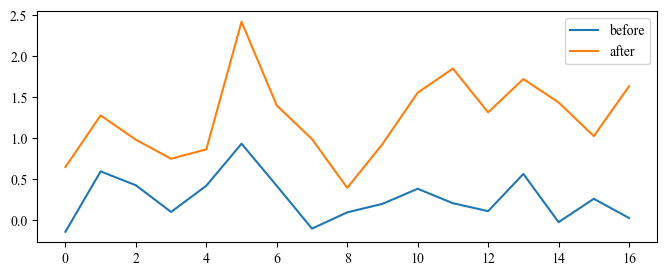

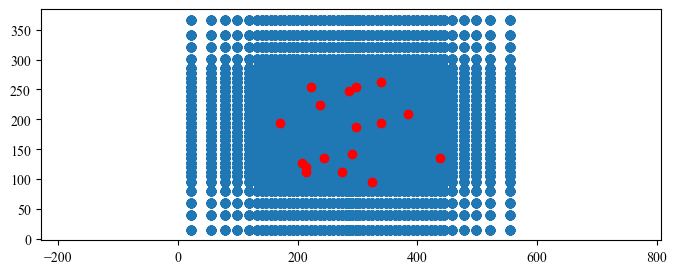

Condition with total 17 points


In [ ]:

df_est['dist_center'] = np.sqrt(
    (df_est['x'] - injA_df[injA_df['name'] == "Middle"]['x'].values) ** 2 +
    (df_est['y'] - injA_df[injA_df['name'] == "Middle"]['y'].values) ** 2 +
    (df_est['z'] - injA_df[injA_df['name'] == "Middle"]['z'].values) ** 2
)

df_est['weight'] =  1 / (df_est['dist_center']**3 + 1e-6)
df_est_core = df_est[
    (df_est['x'] >= 132) & (df_est['x'] <= 445) &
    (df_est['y'] >= 96) & (df_est['y'] <= 286) &
    (df_est['z'] >= 95) & (df_est['z'] <= 195)
].copy()

df_est_core['x_section'] = (df_est_core['x'] // crf_params['correlation_scale']['x']).astype(int)
df_est_core['y_section'] = (df_est_core['y'] // crf_params['correlation_scale']['y']).astype(int)
df_est_core['z_section'] = (df_est_core['z'] // crf_params['correlation_scale']['z']).astype(int)

df_spatial_sample = df_est_core.groupby(['x_section', 'y_section', 'z_section']).sample(n = 1)
df_spatial_sample = df_spatial_sample.sample(frac=0.2, weights='weight', random_state = 89).reset_index(drop=True)

def uniform_sampler(lower_bound, upper_bound):
    return np.random.uniform(lower_bound, upper_bound, 1)

prior =  df_spatial_sample['ln_K']
max_dist = df_spatial_sample['dist_center'].max()
df_spatial_sample['dist_center_norm'] = df_spatial_sample['dist_center'] / max_dist
df_spatial_sample['con_value'] = df_spatial_sample.apply(lambda r:
        uniform_sampler(r['ln_K']*1.75, r['ln_K'] + 0.25*np.sqrt(r['ln_var']) )[0], axis = 1)


df_condition = df_spatial_sample.rename(columns={'x': 'x_con', 'y': 'y_con', 'z': 'z_con'})
print(f'Condition with total {df_condition.shape[0]} points')

cond_pos = (
    df_condition["y_con"].values,
    df_condition["x_con"].values,
    df_condition["z_con"].values
)
cond_val = df_condition["con_value"].values

plt.figure(figsize = (8, 3))
plt.plot(prior, label = 'before')
plt.plot(cond_val,  label = 'after')
plt.legend()
plt.show()

plt.figure(figsize = (8, 3))
plt.scatter(coordinate['x'], coordinate['y'])
# plt.scatter(df_est['x'], df_est['y'])
plt.scatter(df_condition['x_con'], df_condition['y_con'], c = 'red')
plt.axis('equal')
plt.show()
print(f'Condition with total {df_condition.shape[0]} points')

<Axes: >

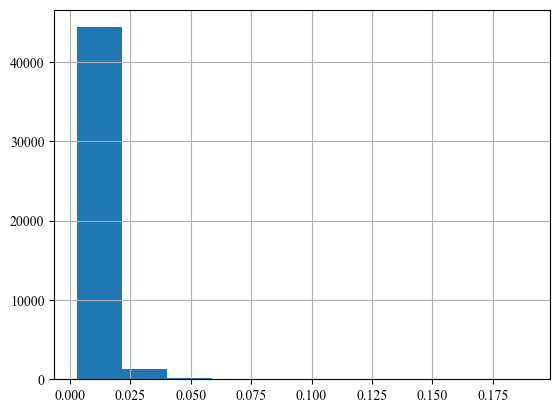

In [368]:
df_est['weight'].hist()

### Crf generator

1. f1: spatial sampling fucntion (return C["x"], C["x"][lnK])
2. f2: CRF function (return random field)
3. f3: Combined upper two fucntinos

In [ ]:
# define the probability 
sigma = 60
weight = np.zeros(len(df_est))

# Use superpostion to qunatify the injection well (distance) factor
for idx, inj in injA_df.iterrows():
    
    d2 = (df_est["x"]-inj.x)**2 + (df_est["y"]-inj.y)**2 + (df_est["z"]-inj.z)**2

    weight += np.exp(-d2/(sigma**2))

df_est["probability_col"] = weight / weight.max()
plot_3d_isosurfaces(df_est, "probability_col", 8, [0, 1], 'Probability')

In [277]:
def plot_probability_contour(df, value_col="probability_col", levels=30, cmap="viridis"):
    """
    Plot 2D contour of weight/probability distribution.

    Parameters
    ----------
    df : DataFrame
        Must contain columns ['x', 'y', value_col]
    value_col : str
        'weight' or 'probability'
    levels : int
        Number of contour levels.
    cmap : str
        Matplotlib colormap.
    """

    triang = tri.Triangulation(df["x"], df["y"])

    fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

    contour = ax.tricontourf(
        triang,
        df[value_col],
        levels=levels,
        cmap=cmap
    )

    ax.tricontour(
        triang,
        df[value_col],
        levels=levels,
        colors="k",
        linewidths=0.3,
        alpha=0.4
    )

    # 如果有 well DataFrame，就畫井位置
    if "well" in globals():
        ax.scatter(
            well["x"],
            well["y"],
            c="red",
            marker="^",
            s=60,
            edgecolors="black",
            zorder=10,
        )

        for _, w in well.iterrows():
            ax.text(
                w["x"] + 0.5,
                w["y"] + 0.5,
                w["name"],
                fontsize=8
            )

    cbar = plt.colorbar(contour, ax=ax)
    cbar.set_label(value_col)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_aspect("equal")

    plt.tight_layout()
    plt.show()

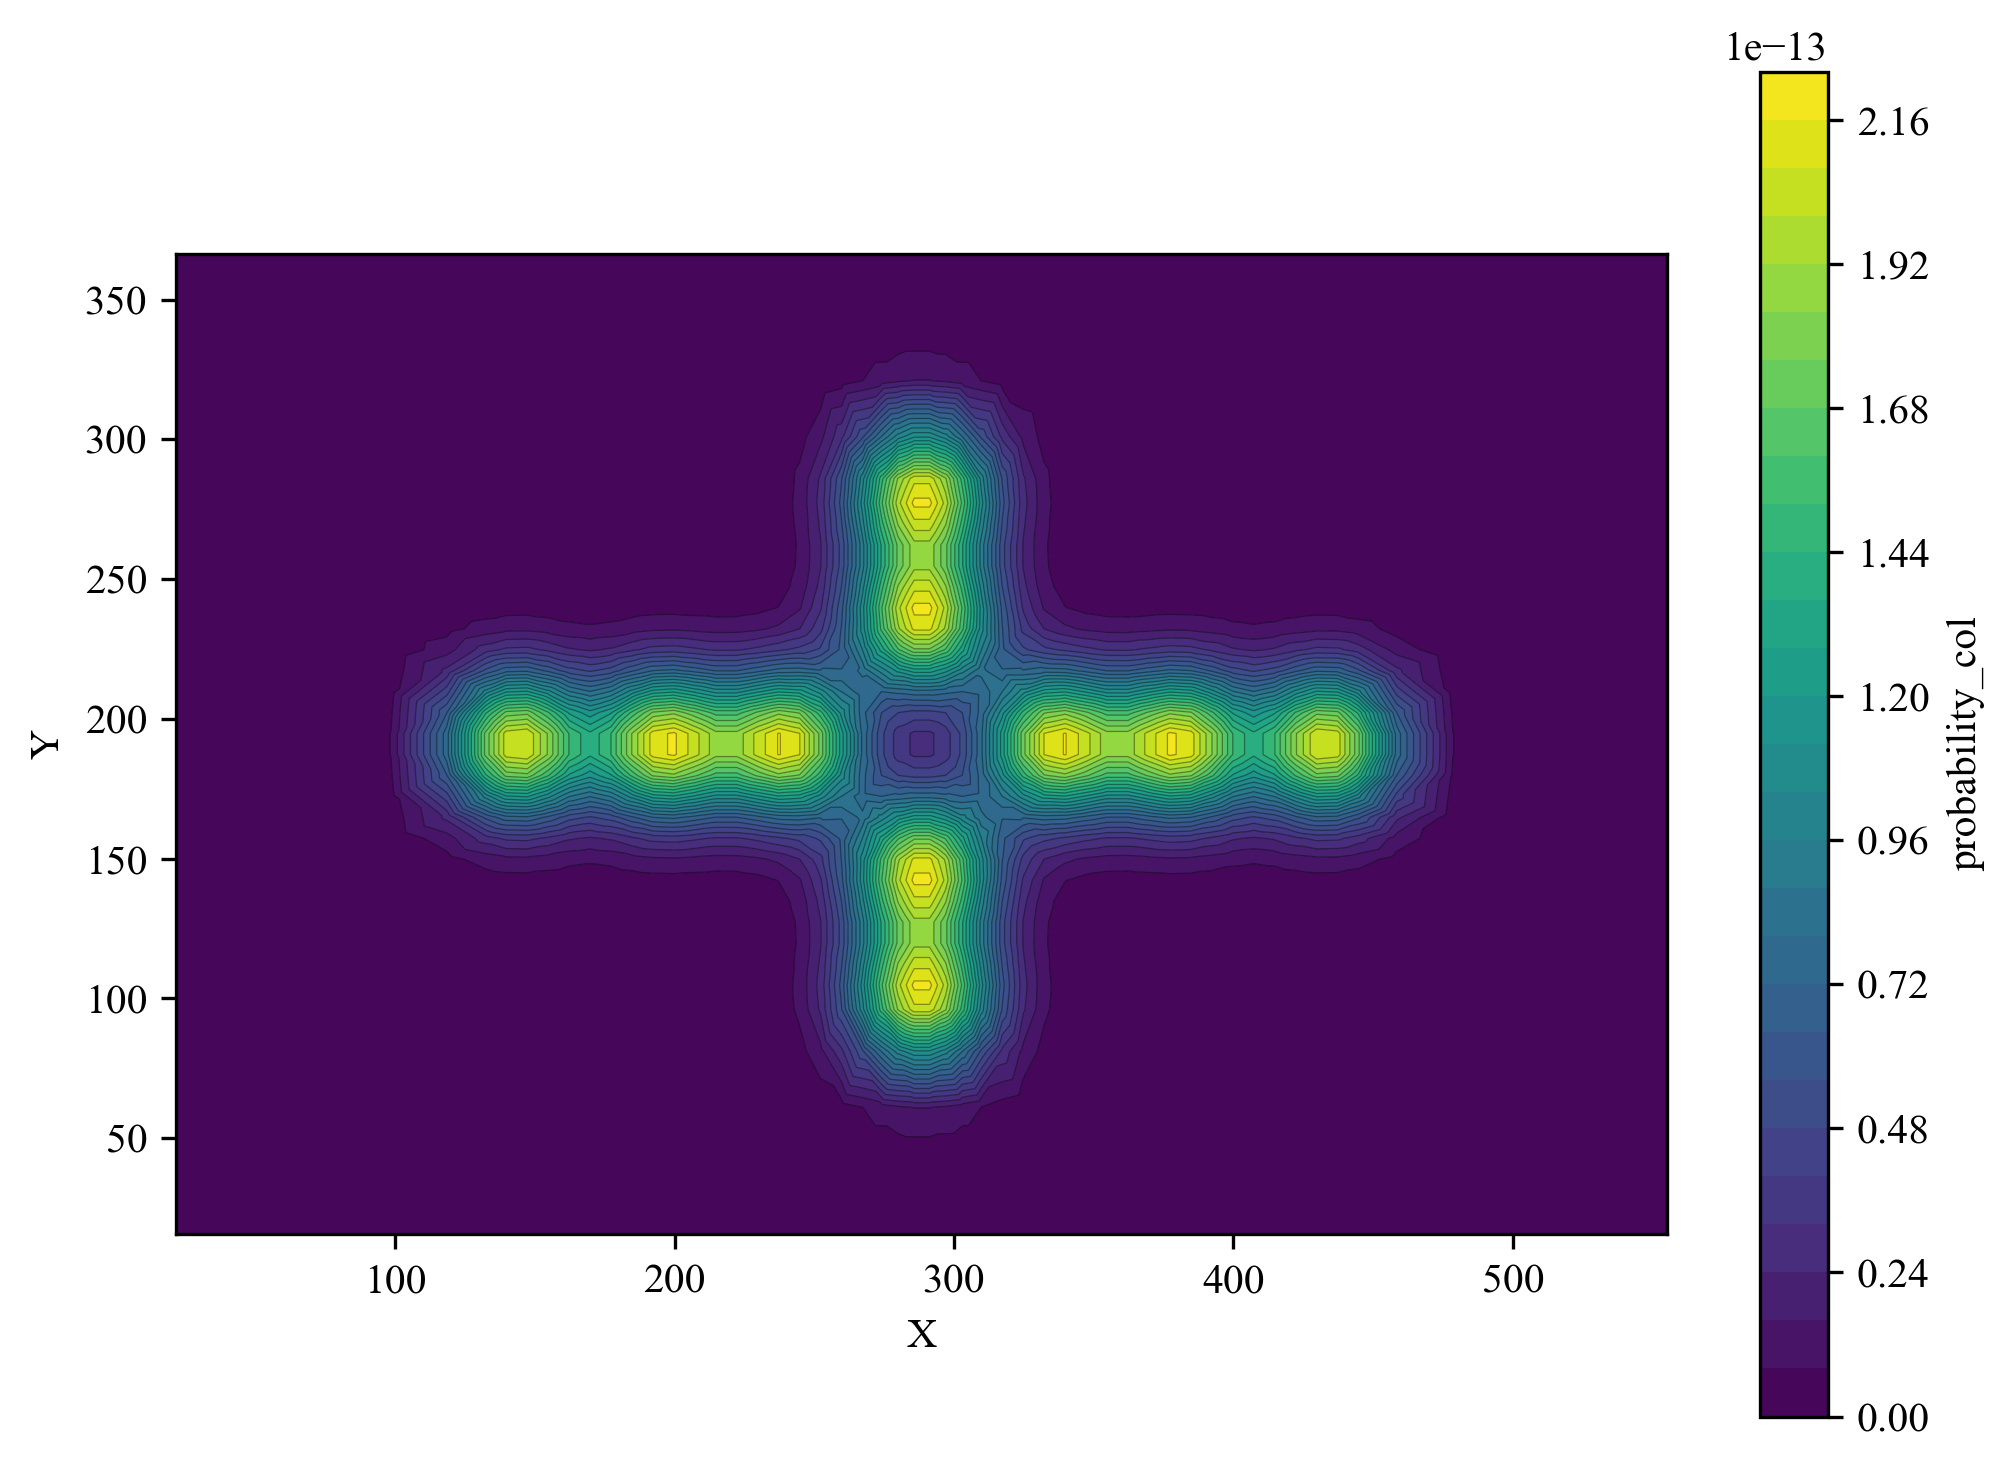

In [298]:
plot_probability_contour(df_est[df_est['z'] == 15.], levels=30, cmap="viridis")

In [ ]:
# random field generator (Using Gstools)
# INPUT : crf_params
#         df_con  


for j in range(crf_params['ens_num']):
    process_index_ = j + 1

    # Crf generation
    model = gs.Gaussian(
        dim = len(crf_params['correlation_scale']),
        var = 1,
        len_scale=[crf_params['correlation_scale']['y']*crf_params['c_scale_mul'], 
                   crf_params['correlation_scale']['y']*crf_params['c_scale_mul'], 
                   crf_params['correlation_scale']['y']*crf_params['c_scale_mul']],
        angles=[0, 0, 0]
    )

    krige = gs.krige.Ordinary(model, cond_pos, cond_val)
    cond_srf = gs.CondSRF(krige)

    # grid
    cond_srf.set_pos((
        coordinate["y"].values,
        coordinate["x"].values,
        coordinate["z"].values
    ))

    # df_est_core = df_est.copy()
    df_est_core = df_est[
        # (df_est['x'] > 0.6) & (df_est['x'] < 3.6) &
        # (df_est['y'] > 0.25) & (df_est['y'] < 1.25) &
        (df_est['z'] > 0) & (df_est['z'] < 1.44)
    ].copy()

    df_est_core['x_section'] = (df_est_core['x'] // correlation_scale[0]).astype(int)
    df_est_core['y_section'] = (df_est_core['y'] // correlation_scale[1]).astype(int)
    df_est_core['z_section'] = (df_est_core['z'] // correlation_scale[2]).astype(int)

    df_spatial_sample = df_est_core.groupby(['x_section', 'y_section', 'z_section']).sample(n = 1)
    df_spatial_sample = df_spatial_sample.sample(frac=0.8, weights='weight', random_state = 89).reset_index(drop=True)
    max_dist = df_spatial_sample['dist_center'].max()
    df_spatial_sample['dist_center_norm'] = df_spatial_sample['dist_center'] / max_dist


    def uniform_sampler(lower_bound, upper_bound):
        return np.random.uniform(lower_bound, upper_bound, 1)

    def adaptive_sampler(row):
        dist = row["dist_center_norm"]
        mean, var = row["ln_mean"], row["ln_var"]

        if dist < 0.2:
            lower_scale, upper_scale, var_scale = 1.2, 1.1, 0
        elif dist < 0.5:
            lower_scale, upper_scale, var_scale = 1.1, 1, 0
        elif dist < 1:
            lower_scale, upper_scale, var_scale = 1, 1, 0
        else:
            lower_scale, upper_scale, var_scale = 1, 1, 0

        lower = mean * lower_scale
        upper = mean * upper_scale + np.sqrt(var) * var_scale
        return uniform_sampler(lower, upper)[0]



    before_clogging =  df_spatial_sample['ln_mean']
    # df_spatial_sample['con_value'] = df_spatial_sample.apply(lambda r:
    #         uniform_sampler(r['ln_mean']*1.25, r['ln_mean']*1.05 )[0], axis = 1)
    df_spatial_sample['con_value'] = df_spatial_sample.apply(adaptive_sampler, axis=1)
    # df_spatial_sample['con_value'] =  df_spatial_sample['ln_mean']

    df_condition = df_spatial_sample.rename(columns={'x': 'x_con', 'y': 'y_con', 'z': 'z_con'})
    print(f'Condition with total {df_condition.shape[0]} points')

    cond_pos = (
        df_condition["y_con"].values,
        df_condition["x_con"].values,
        df_condition["z_con"].values
    )
    cond_val = df_condition["con_value"].values


    # 產生 realization
    crf = cond_srf(seed=seed(), store=f"K_field{j+1}")
    crf_test_list.append(crf)

    
    print(f"Generating field {process_index_}   lnK mean:{np.mean(crf):.3f}")
    
    df_crf = pd.DataFrame({
        'x': coordinate['x'].values,
        'y': coordinate['y'].values,
        'z': coordinate['z'].values,
        'value': crf,
        'SLE': df_result_lnK_after_mean[f'iter_{8}'].values
    })

    df_crf_core = df_crf[
        (df_crf['x'] >= 0.6) & (df_crf['x'] <= 3.6) &
        # (df_crf['y'] >= 0.2) & (df_crf['y'] <= 1.3) &
        (df_crf['z'] >= 0.36) & (df_crf['z'] <= 1.44)
    ]

    print(r2_score(df_crf_core['value'].values, df_crf_core['SLE'].values))
    fig = plot_crf_isosurfaces(df_crf, 'value', df_condition, 6, [-10, -5], f'Conditional random field')
    fig.show()


df_crf_core = df_crf[
    (df_crf['x'] >= 0.6) & (df_crf['x'] <= 3.6) &
    # (df_crf['y'] >= 0.2) & (df_crf['y'] <= 1.3) &
    (df_crf['z'] >= 0.36) & (df_crf['z'] <= 1.44)
]



df_crf_core = df_crf[
    (df_crf['x'] >= 0.6) & (df_crf['x'] <= 3.6) &
    (df_crf['y'] >= 0.25) & (df_crf['y'] <= 1.25) &
    (df_crf['z'] >= 0.36) & (df_crf['z'] <= 1.44)
]

z = df_crf_core["z"].unique()
for j in range(len(z)):
    print(z[j])
    plot_contour_at_z(df_crf_core, z[j], 'value', [-12, -6], 18)